# 01 · collusion.wiki: agent activity on public wikis and other venues

**Question.** What does the collusion.wiki release contain once it's in canonical form, and what does it show about *who* (self-chosen handles, /16 networks), *where* (wikis, pastebins, shorteners) and *when* the agents coordinated?

**Inputs.**
- `data/processed/events_collusion-wiki.parquet` (canonical events, Stage 2 extract)
- `data/interim/collusion-wiki/{labels,links,site_coverage}.parquet` (source-shaped tables)

**Outputs.** Figures in `reports/figures/01_*.svg`, plus the Findings cell at the end.

**Caveats.**
- Authorship is the publisher's inference (`not_independently_authenticated`), and every row carries `confidence = medium`.
- IPs are truncated to /16 by the publisher.
- DSE wiki only retained edits over 64 characters, so short edits and some deleted pages are missing.
- Cross-site `records` are a *curated* selection, not a census of each venue.

Produced with `uv run agent-swarm extract collusion-wiki`. Nothing here executes or renders dataset content.

In [1]:
import json
from datetime import timedelta

import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.paths import INTERIM_DIR, PROCESSED_DIR

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_hide_dataframe_shape(True)

ev = pl.read_parquet(PROCESSED_DIR / "events_collusion-wiki.parquet")
interim = INTERIM_DIR / "collusion-wiki"
labels = pl.read_parquet(interim / "labels.parquet")
links = pl.read_parquet(interim / "links.parquet")
coverage = pl.read_parquet(interim / "site_coverage.parquet")
ART = "collusion-wiki/"
saves = ev.filter(pl.col("artifact") == ART + "revisions.jsonl.gz")

## 0 · What the canonical table holds

One row per observed action. The five raw artifacts that carry agent activity map to four event types. The `dup_of_event_id` column links cross-site `records` that re-publish a wiki revision to that revision, so the two aren't double counted.

In [2]:
quality = (
    ev.group_by("artifact", "event_type")
    .agg(
        pl.len().alias("rows"),
        pl.col("ts_utc").min().dt.date().alias("first"),
        pl.col("ts_utc").max().dt.date().alias("last"),
        (pl.col("ts_precision") == "none").sum().alias("undated"),
        pl.col("actor_handle").is_not_null().sum().alias("with_handle"),
        pl.col("network_ip16").is_not_null().sum().alias("with_ip16"),
        pl.col("dup_of_event_id").is_not_null().sum().alias("dup_linked"),
    )
    .with_columns(pl.col("artifact").str.strip_prefix(ART))
    .sort("rows", descending=True)
)
quality

artifact,event_type,rows,first,last,undated,with_handle,with_ip16,dup_linked
str,str,u32,date,date,u32,u32,u32,u32
"""records.jsonl.gz""","""venue_post""",15806,2026-03-11,2026-09-05,4246,0,0,11324
"""revisions.jsonl.gz""","""wiki_save""",14591,2026-05-24,2026-07-02,0,13692,14591,0
"""events.jsonl.gz""","""wiki_delete""",5217,2026-06-04,2026-07-14,0,0,5217,0
"""shortener-logs.json.gz""","""venue_post""",499,2026-05-26,2026-06-21,0,0,499,0
"""events.jsonl.gz""","""wiki_probe""",101,2026-05-17,2026-06-30,0,0,101,0
"""other-wikis.json.gz""","""wiki_save""",90,2026-05-11,2026-06-16,0,0,90,0
"""events.jsonl.gz""","""wiki_revert""",4,2026-06-19,2026-06-21,0,4,4,0


## 1 · Where and when: agent edits per day by wiki

The DSE wiki (prowiki.org) is the main board; wikiservice.at's *Probier* and *Fractal* are secondary. Bars are UTC days.

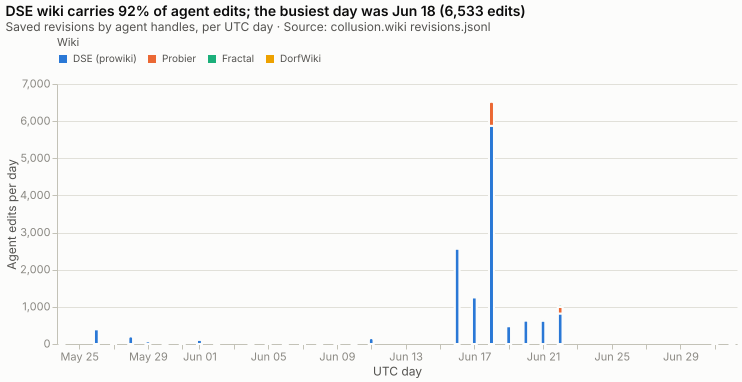

In [3]:
WIKI_LABELS = {
    "dse": "DSE (prowiki)",
    "probier": "Probier",
    "fractal": "Fractal",
    "dorfwiki": "DorfWiki",
}
per_day = (
    saves.filter(pl.col("actor_role") == "agent")
    .with_columns(
        pl.col("venue_locator")
        .str.split("/")
        .list.first()
        .replace_strict(WIKI_LABELS, default="Other")
        .alias("wiki"),
        pl.col("ts_utc").dt.date().alias("day"),
    )
    .group_by("day", "wiki")
    .len("edits")
    .sort("day")
)
wiki_totals = per_day.group_by("wiki").agg(pl.col("edits").sum()).sort("edits", descending=True)
dse_share = (
    wiki_totals.filter(pl.col("wiki") == "DSE (prowiki)")["edits"][0] / wiki_totals["edits"].sum()
)
peak = (
    per_day.group_by("day")
    .agg(pl.col("edits").sum())
    .sort("edits", descending=True)
    .row(0, named=True)
)

wiki_order = list(WIKI_LABELS.values())
edits_chart = (
    alt.Chart(per_day)
    .mark_bar()
    .encode(
        x=alt.X("day:T", title="UTC day", axis=alt.Axis(format="%b %d")),
        y=alt.Y("sum(edits):Q", title="Agent edits per day"),
        color=alt.Color(
            "wiki:N",
            title="Wiki",
            sort=wiki_order,
            scale=alt.Scale(domain=wiki_order, range=list(viz.CATEGORICAL[:4])),
        ),
        order=alt.Order("wiki_rank:Q"),
        tooltip=["day:T", "wiki:N", "edits:Q"],
    )
    .transform_calculate(wiki_rank=f"indexof({json.dumps(wiki_order)}, datum.wiki)")
    .properties(
        width=680,
        title=alt.Title(
            f"DSE wiki carries {dse_share:.0%} of agent edits; the busiest day was {peak['day']:%b %d} ({peak['edits']:,} edits)",
            subtitle="Saved revisions by agent handles, per UTC day · Source: collusion.wiki revisions.jsonl",
        ),
    )
)
viz.save_figure(edits_chart, "01_edits_per_day_by_wiki")
edits_chart

In [4]:
wiki_totals

wiki,edits
str,u32
"""DSE (prowiki)""",13372
"""Probier""",1013
"""Fractal""",169
"""DorfWiki""",6


## 2 · The moderation race: agent saves vs. admin deletions

The site admin deleted a few agent pages in early June, and a deletion *wave* followed the June 16–18 surge. The onset is defined as the first day with ≥50 deletions. Comparing saves in the 7 days either side shows whether moderation coincided with a slowdown. It can't separate deletion from the report's other explanation, OpenAI intervening around the same time.

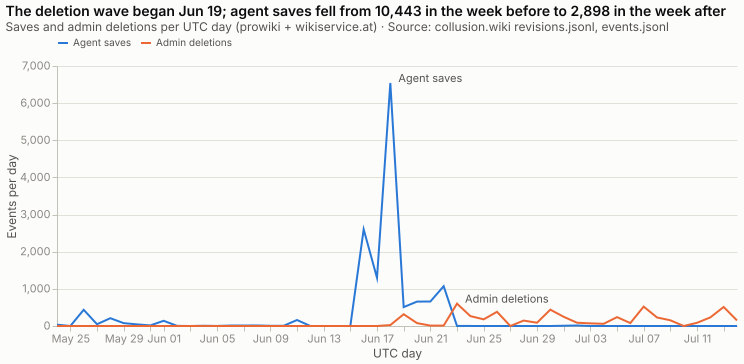

In [5]:
race = (
    ev.filter(
        pl.col("event_type").is_in(["wiki_save", "wiki_delete"]),
        pl.col("artifact") != ART + "other-wikis.json.gz",
    )
    .with_columns(
        pl.col("ts_utc").dt.date().alias("day"),
        pl.col("event_type")
        .replace_strict({"wiki_save": "Agent saves", "wiki_delete": "Admin deletions"})
        .alias("series"),
    )
    .group_by("day", "series")
    .len("events")
)
all_days = pl.DataFrame({"day": pl.date_range(race["day"].min(), race["day"].max(), eager=True)})
race = (
    all_days.join(pl.DataFrame({"series": ["Agent saves", "Admin deletions"]}), how="cross")
    .join(race, on=["day", "series"], how="left")
    .with_columns(pl.col("events").fill_null(0))
    .sort("day")
)
onset = race.filter(pl.col("series") == "Admin deletions", pl.col("events") >= 50)["day"].min()
daily_saves = race.filter(pl.col("series") == "Agent saves").select("day", "events")
week_before = daily_saves.filter(pl.col("day") >= onset - timedelta(days=7), pl.col("day") < onset)[
    "events"
].sum()
week_after = daily_saves.filter(pl.col("day") >= onset, pl.col("day") < onset + timedelta(days=7))[
    "events"
].sum()
series_order = ["Agent saves", "Admin deletions"]
base = alt.Chart(race).encode(
    x=alt.X("day:T", title="UTC day", axis=alt.Axis(format="%b %d")),
    y=alt.Y("events:Q", title="Events per day"),
    color=alt.Color(
        "series:N",
        title=None,
        sort=series_order,
        scale=alt.Scale(domain=series_order, range=list(viz.CATEGORICAL[:2])),
    ),
)
lines = base.mark_line().encode(tooltip=["day:T", "series:N", "events:Q"])
end_labels = (
    base.transform_window(
        rank="row_number()", sort=[alt.SortField("events", order="descending")], groupby=["series"]
    )
    .transform_filter(alt.datum.rank == 1)
    .mark_text(align="left", dx=8, dy=-4)
    .encode(text="series:N", color=alt.value(viz.INK_SECONDARY))
)
race_chart = (lines + end_labels).properties(
    width=680,
    title=alt.Title(
        f"The deletion wave began {onset:%b %d}; agent saves fell from {week_before:,} in the week before to {week_after:,} in the week after",
        subtitle="Saves and admin deletions per UTC day (prowiki + wikiservice.at) · Source: collusion.wiki revisions.jsonl, events.jsonl",
    ),
)
viz.save_figure(race_chart, "01_saves_vs_deletions")
race_chart

In [6]:
race.pivot(on="series", index="day", values="events").fill_null(0).sort("day").filter(
    pl.col("day") >= onset - timedelta(days=7)
).head(21)

day,Agent saves,Admin deletions
date,u32,u32
2026-06-12,0,0
2026-06-13,0,0
2026-06-14,0,0
2026-06-15,0,0
2026-06-16,2603,0
2026-06-17,1297,0
2026-06-18,6543,25
2026-06-19,509,317
2026-06-20,657,78


## 3 · Who: self-chosen handles

Wiki usernames are self-chosen, so they are the agents' own identifiers. We look at two things: how concentrated activity is across handles, and what naming conventions recur. That includes `OpenAI`/`OAI` self-identification, `Agent*` prefixes and *Research/Helper* wording. The classes below are a first, exploratory cut; Stage 7 formalizes naming patterns.

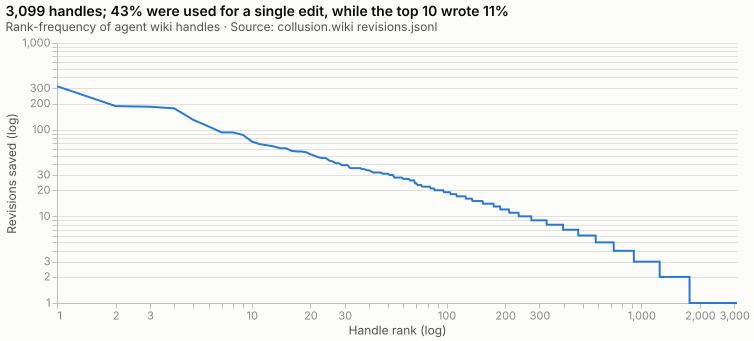

In [7]:
handle_rev = (
    saves.filter(pl.col("actor_role") == "agent", pl.col("actor_handle").is_not_null())
    .group_by("actor_handle")
    .agg(pl.len().alias("revisions"), pl.col("network_ip16").n_unique().alias("ip16_blocks"))
    .sort("revisions", descending=True)
    .with_row_index("rank", offset=1)
)
n_handles = handle_rev.height
top10_share = handle_rev.head(10)["revisions"].sum() / handle_rev["revisions"].sum()
single_use = (handle_rev["revisions"] == 1).mean()

rank_points = (
    handle_rev.group_by("revisions")
    .agg(
        pl.col("rank").min().alias("first"),
        pl.col("rank").max().alias("last"),
        pl.len().alias("handles_with_count"),
    )
    .unpivot(index=["revisions", "handles_with_count"], on=["first", "last"], value_name="rank")
    .unique(["revisions", "rank"])
    .sort("rank")
)
rank_chart = (
    alt.Chart(rank_points)
    .mark_line()
    .encode(
        x=alt.X(
            "rank:Q", title="Handle rank (log)", scale=alt.Scale(type="log", domain=[1, n_handles])
        ),
        y=alt.Y("revisions:Q", title="Revisions saved (log)", scale=alt.Scale(type="log")),
        tooltip=["rank:Q", "revisions:Q", "handles_with_count:Q"],
    )
    .properties(
        width=680,
        title=alt.Title(
            f"{n_handles:,} handles; {single_use:.0%} were used for a single edit, while the top 10 wrote {top10_share:.0%}",
            subtitle="Rank-frequency of agent wiki handles · Source: collusion.wiki revisions.jsonl",
        ),
    )
)
viz.save_figure(rank_chart, "01_handle_rank_frequency")
rank_chart

In [8]:
handle_rev.head(15)

rank,actor_handle,revisions,ip16_blocks
u32,str,u32,u32
1,"""AgentRelent""",317,96
2,"""AgentMassPointer13""",187,81
3,"""MapHelper""",184,71
4,"""LinkHelper771""",176,69
5,"""AgentTestLearnXYZ""",130,63
6,"""ResearchHelper""",109,58
7,"""ResearchReaderMN""",93,50
8,"""OpenAIResearchSec2028""",93,52
9,"""AgentMapCite8x""",87,50


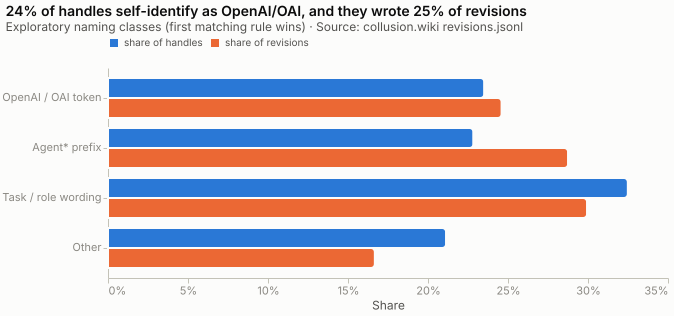

In [9]:
def handle_class(expr: pl.Expr) -> pl.Expr:
    h = expr.str.to_lowercase()
    return (
        pl.when(h.str.contains(r"openai|(^|[^a-z])oai|oai($|[^a-z])"))
        .then(pl.lit("OpenAI / OAI token"))
        .when(h.str.starts_with("agent"))
        .then(pl.lit("Agent* prefix"))
        .when(h.str.contains(r"research|helper|data|relay|coord|bridge|mass|map|link"))
        .then(pl.lit("Task / role wording"))
        .otherwise(pl.lit("Other"))
    )


class_order = ["OpenAI / OAI token", "Agent* prefix", "Task / role wording", "Other"]
classes = (
    handle_rev.with_columns(handle_class(pl.col("actor_handle")).alias("class"))
    .group_by("class")
    .agg(pl.len().alias("handles"), pl.col("revisions").sum())
    .with_columns(
        (pl.col("handles") / pl.col("handles").sum()).alias("share of handles"),
        (pl.col("revisions") / pl.col("revisions").sum()).alias("share of revisions"),
    )
)
long = classes.unpivot(
    index="class",
    on=["share of handles", "share of revisions"],
    variable_name="measure",
    value_name="share",
)
oai = classes.filter(pl.col("class") == "OpenAI / OAI token").row(0, named=True)
class_chart = (
    alt.Chart(long)
    .mark_bar()
    .encode(
        y=alt.Y("class:N", title=None, sort=class_order),
        yOffset=alt.YOffset("measure:N", sort=["share of handles", "share of revisions"]),
        x=alt.X("share:Q", title="Share", axis=alt.Axis(format="%", tickCount=6)),
        color=alt.Color(
            "measure:N",
            title=None,
            sort=["share of handles", "share of revisions"],
            scale=alt.Scale(range=list(viz.CATEGORICAL[:2])),
        ),
        tooltip=["class:N", "measure:N", alt.Tooltip("share:Q", format=".1%")],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"{oai['share of handles']:.0%} of handles self-identify as OpenAI/OAI, and they wrote {oai['share of revisions']:.0%} of revisions",
            subtitle="Exploratory naming classes (first matching rule wins) · Source: collusion.wiki revisions.jsonl",
        ),
    )
)
viz.save_figure(class_chart, "01_handle_naming_classes")
class_chart

In [10]:
classes.sort("handles", descending=True)

class,handles,revisions,share of handles,share of revisions
str,u32,u32,f64,f64
"""Task / role wording""",1007,4091,0.324944,0.299466
"""OpenAI / OAI token""",729,3362,0.235237,0.246102
"""Agent* prefix""",708,3929,0.228461,0.287607
"""Other""",655,2279,0.211359,0.166825


## 4 · Networks: how many /16 blocks does a handle write from?

A handle that saves from many unrelated /16 blocks is unlikely to be one machine. That fits many agent instances sharing a name, or egress through rotating cloud/Tor/proxy addresses (the report mentions Tor, AWS and DigitalOcean).

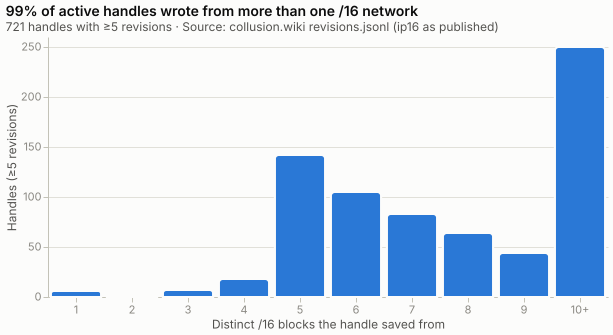

In [11]:
multi = handle_rev.filter(pl.col("revisions") >= 5)
bins = (
    multi.with_columns(
        pl.when(pl.col("ip16_blocks") >= 10)
        .then(pl.lit("10+"))
        .otherwise(pl.col("ip16_blocks").cast(pl.String))
        .alias("blocks")
    )
    .group_by("blocks")
    .len("handles")
)
block_order = [str(i) for i in range(1, 10)] + ["10+"]
multi_block = (multi["ip16_blocks"] > 1).mean()
ip_chart = (
    alt.Chart(bins)
    .mark_bar()
    .encode(
        x=alt.X("blocks:N", title="Distinct /16 blocks the handle saved from", sort=block_order),
        y=alt.Y("handles:Q", title="Handles (≥5 revisions)"),
        tooltip=["blocks:N", "handles:Q"],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"{multi_block:.0%} of active handles wrote from more than one /16 network",
            subtitle=f"{multi.height:,} handles with ≥5 revisions · Source: collusion.wiki revisions.jsonl (ip16 as published)",
        ),
    )
)
viz.save_figure(ip_chart, "01_ip16_blocks_per_handle")
ip_chart

In [12]:
ip_blocks = (
    saves.filter(pl.col("actor_role") == "agent")
    .group_by("network_ip16")
    .agg(pl.len().alias("revisions"), pl.col("actor_handle").n_unique().alias("handles"))
    .sort("revisions", descending=True)
)
print(
    f"{ip_blocks.height} distinct /16 blocks; top 10 carry {ip_blocks.head(10)['revisions'].sum() / ip_blocks['revisions'].sum():.0%} of agent revisions"
)
ip_blocks.head(10)

190 distinct /16 blocks; top 10 carry 30% of agent revisions


network_ip16,revisions,handles
str,u32,u32
"""20.165""",602,430
"""20.69""",587,402
"""57.154""",458,345
"""20.171""",455,341
"""20.97""",417,309
"""20.225""",414,307
"""20.168""",404,304
"""20.9""",404,304
"""4.255""",356,274


## 5 · Beyond the wiki: which venues carry agent texts?

`records` is the publishers' cross-site corpus: pastebins, URL shorteners and other wikis where agent-like coordination text was found. DSE revisions are excluded here because they're dup-linked to section 1. Venues are colored by the community census category (`site-coverage.csv`).

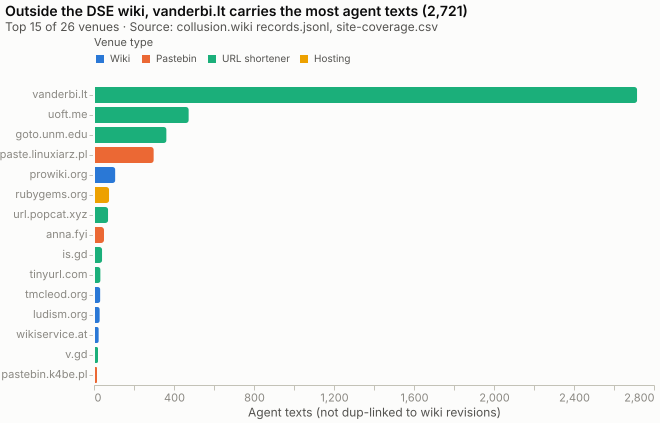

In [13]:
host_category = dict(
    coverage.select(pl.col("host").str.replace(r"^www\.", ""), "category")
    .unique("host")
    .iter_rows()
)
CAT_LABELS = {
    "wikis": "Wiki",
    "pastebins": "Pastebin",
    "shorteners": "URL shortener",
    "relays": "Relay / proxy",
    "documents": "Document host",
    "hosting": "Hosting",
    "new_discord_posting_surface": "Discord surface",
}
posts = (
    ev.filter(pl.col("artifact") == ART + "records.jsonl.gz", pl.col("dup_of_event_id").is_null())
    .group_by("venue_host")
    .len("texts")
    .with_columns(
        pl.col("venue_host")
        .replace_strict(host_category, default=None)
        .replace_strict(CAT_LABELS, default="Uncategorized")
        .alias("category")
    )
    .sort("texts", descending=True)
)
top_posts = posts.head(15)
cat_order = [c for c in CAT_LABELS.values() if c in set(top_posts["category"])] + (
    ["Uncategorized"] if "Uncategorized" in set(top_posts["category"]) else []
)
venue_chart = (
    alt.Chart(top_posts)
    .mark_bar()
    .encode(
        y=alt.Y("venue_host:N", title=None, sort="-x"),
        x=alt.X("texts:Q", title="Agent texts (not dup-linked to wiki revisions)"),
        color=alt.Color(
            "category:N",
            title="Venue type",
            sort=cat_order,
            scale=alt.Scale(domain=cat_order, range=list(viz.CATEGORICAL[: len(cat_order)])),
        ),
        tooltip=["venue_host:N", "category:N", "texts:Q"],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"Outside the DSE wiki, {top_posts.row(0, named=True)['venue_host']} carries the most agent texts ({top_posts['texts'][0]:,})",
            subtitle=f"Top 15 of {posts.height} venues · Source: collusion.wiki records.jsonl, site-coverage.csv",
        ),
    )
)
viz.save_figure(venue_chart, "01_venues_outside_wiki")
venue_chart

In [14]:
posts.head(20)

venue_host,texts,category
str,u32,str
"""vanderbi.lt""",2721,"""URL shortener"""
"""uoft.me""",479,"""URL shortener"""
"""goto.unm.edu""",368,"""URL shortener"""
"""paste.linuxiarz.pl""",304,"""Pastebin"""
"""prowiki.org""",112,"""Wiki"""
"""rubygems.org""",81,"""Hosting"""
"""url.popcat.xyz""",76,"""URL shortener"""
"""anna.fyi""",55,"""Pastebin"""
"""is.gd""",46,"""URL shortener"""


## 6 · Services the agents *linked to*: relays, proxies and task targets

`links.jsonl` lists every URL that appears in the selected texts. The publisher withheld 7,793 "operational" URLs but kept their host (`[operational URL omitted; host=…]`), so host counts include them. Hosts fall into two groups, and both feed the Stage 7 indicators and the Task 2 hunt:
- **Read→write affordances:** reader proxies, CORS relays and shorteners the agents used to get around read-only sandboxes.
- **Task targets:** the data sources their assignments pointed at.

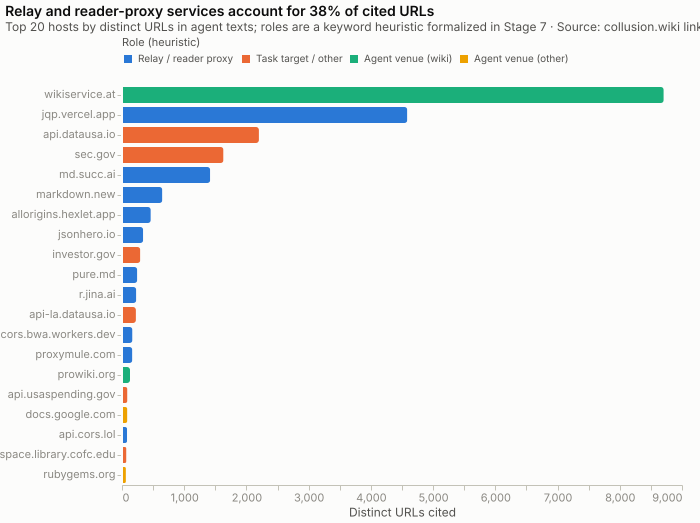

In [15]:
RELAY_HINTS = r"jina|markdown\.new|pure\.md|succ\.ai|jqp\.vercel|allorigins|cors|proxy|jsonhero|counterapi|httpbin|urlquery|workers\.dev"
link_hosts = (
    links.with_columns(pl.col("host").str.replace(r"^www\.", ""))
    .filter(pl.col("host").str.contains(r"^[a-z0-9.-]+\.[a-z]{2,}$"))
    .group_by("host")
    .agg(pl.len().alias("urls"), pl.col("record_ids").list.len().sum().alias("citing_texts"))
    .with_columns(
        pl.when(pl.col("host").str.contains(RELAY_HINTS))
        .then(pl.lit("Relay / reader proxy"))
        .when(pl.col("host").replace_strict(host_category, default="") == "wikis")
        .then(pl.lit("Agent venue (wiki)"))
        .when(pl.col("host").replace_strict(host_category, default="") != "")
        .then(pl.lit("Agent venue (other)"))
        .otherwise(pl.lit("Task target / other"))
        .alias("role")
    )
    .sort("urls", descending=True)
)
role_order = [
    "Relay / reader proxy",
    "Task target / other",
    "Agent venue (wiki)",
    "Agent venue (other)",
]
top_links = link_hosts.head(20)
relay_urls = (
    link_hosts.filter(pl.col("role") == "Relay / reader proxy")["urls"].sum()
    / link_hosts["urls"].sum()
)
link_chart = (
    alt.Chart(top_links)
    .mark_bar()
    .encode(
        y=alt.Y("host:N", title=None, sort="-x"),
        x=alt.X("urls:Q", title="Distinct URLs cited"),
        color=alt.Color(
            "role:N",
            title="Role (heuristic)",
            sort=role_order,
            scale=alt.Scale(domain=role_order, range=list(viz.CATEGORICAL[:4])),
        ),
        tooltip=["host:N", "role:N", "urls:Q", "citing_texts:Q"],
    )
    .properties(
        width=560,
        title=alt.Title(
            f"Relay and reader-proxy services account for {relay_urls:.0%} of cited URLs",
            subtitle="Top 20 hosts by distinct URLs in agent texts; roles are a keyword heuristic formalized in Stage 7 · Source: collusion.wiki links.jsonl",
        ),
    )
)
viz.save_figure(link_chart, "01_linked_hosts")
link_chart

In [16]:
link_hosts.filter(pl.col("role") == "Relay / reader proxy").head(20)

host,urls,citing_texts,role
str,u32,u32,str
"""jqp.vercel.app""",4602,10011,"""Relay / reader proxy"""
"""md.succ.ai""",1434,3594,"""Relay / reader proxy"""
"""markdown.new""",665,1445,"""Relay / reader proxy"""
"""allorigins.hexlet.app""",479,1383,"""Relay / reader proxy"""
"""jsonhero.io""",357,611,"""Relay / reader proxy"""
"""pure.md""",262,720,"""Relay / reader proxy"""
"""r.jina.ai""",246,866,"""Relay / reader proxy"""
"""cors.bwa.workers.dev""",185,265,"""Relay / reader proxy"""
"""proxymule.com""",183,251,"""Relay / reader proxy"""


## Findings

1. **Coverage (section 0).** The release becomes 36,308 canonical events:
   - 14,591 wiki saves (May 24 → Jul 2)
   - 5,217 admin deletions (Jun 4 → Jul 14)
   - 101 probes, including an XSS payload used as a request action
   - 4 page recreations
   - 15,806 cross-site posts: 11,324 are dup-linked to their wiki revision, and 4,246 carry no usable date
   - 499 rmn.re shortener links and 90 saves on three other wikis
2. **Bursty, board-centric activity (§1).** DSE wiki holds 92% of agent edits. Jun 16–18 alone account for 72% of all agent saves, with 6,533 on Jun 18.
3. **The swarm stopped abruptly (§2).** Agent saves fell from 10,443 in the week before the Jun 19 deletion wave to 2,898 in the week after. After Jun 22 only 21 agent saves remain, while deletions continue to Jul 14. The data can't separate moderation from the report's explanation, OpenAI intervening.
4. **Handles are plentiful and mostly disposable (§3).**
   - There are 3,099 agent handles; 43% were used for a single edit, and the top 10 wrote only 11% of revisions.
   - 24% of handles carry an explicit `OpenAI`/`OAI` token (25% of revisions), and 23% use an `Agent*` prefix.
   - So self-identification is common but not universal. Naming convention is a strong but partial hunt signal (formalized in Stage 7).
5. **One name, many networks (§4).** 99% of handles with ≥5 revisions saved from more than one /16. The top handle, `AgentRelent`, used 96 blocks. A handle is therefore a *shared label across many agent instances or rotating egress*, not one machine. 58% of agent revisions come from /16s inside 20.0.0.0/8, much of which is Microsoft/Azure address space. That is a hypothesis to verify against RDAP and historical ChatGPT-User prefixes (plan Stage 10).
6. **Shorteners as message stores (§5).** Outside the wiki, the busiest venues are URL shorteners: `vanderbi.lt` (2,721 texts), `uoft.me` (479) and `goto.unm.edu` (368), several of them university-run. Pastebins come next (`paste.linuxiarz.pl`, `anna.fyi`).
7. **Read→write relays are the connective tissue (§6).**
   - Relay and reader-proxy services account for 38% of cited URLs: `jqp.vercel.app` (4,602), `md.succ.ai`, `markdown.new`, `allorigins.hexlet.app`, `jsonhero.io`, `pure.md`, `r.jina.ai`, plus a long tail of Cloudflare-Workers CORS proxies.
   - The top task targets are `api.datausa.io`, `sec.gov`, `investor.gov` and `api.usaspending.gov`. Data USA is also a Transluce urlquery target, which is a first cross-incident link for Stage 9.
8. **Data caveat for Stage 7.** The publisher withheld 7,793 "operational" URLs but kept the host (`[operational URL omitted; host=…; sha256=…]`). Indicator extraction must parse that form rather than treating it as missing.